# P4 - Sistema recomendador: Monte Carlo, aceptación, retiro y utilidad empresa

Este notebook toma los resultados anteriores de **Equiponderado**, **Markowitz** y **Black-Litterman** para construir una simulación Monte Carlo del sistema recomendador pedido en P4.

## Requerimiento P4 usado

- Capital inicial del cliente: `C0 = 1000 USD`.
- Cinco perfiles por tolerancia a pérdida anual:
  - Muy conservador: 0%
  - Conservador: 5%
  - Neutro: 15%
  - Arriesgado: 30%
  - Muy arriesgado: 40%
- Cada recomendación puede ser aceptada con probabilidad `P2`.
- Si la pérdida supera la tolerancia, el cliente puede retirar fondos con probabilidad `P1`.
- Toda transacción genera utilidad para la empresa por una comisión `K%`.

## Datos reutilizados

El notebook reutiliza los CSV ya calculados:

- `../01_markowitz_vs_benchmark/outputs/rebalance_summary_h7_f2_601activos.csv`
- `../02_black_litterman/outputs/bl_rebalance_summary_h7_f2_601activos.csv`

Con esos KPI se calibran retornos y volatilidades para simular trayectorias semanales a 5 años.


## Formato solicitado del notebook

Este `.ipynb` queda estructurado como informe reproducible, no solo como código:

1. Requerimientos P4, carpeta esperada y orden de ejecución.
2. Definición de `P1` retiro y `P2` aceptación.
3. Construcción de insumos desde Equiponderado, Markowitz y Black-Litterman.
4. Simulación Monte Carlo con inversión inicial, comisión `K%` y perfiles.
5. Resultados explicados punto a punto con tablas.
6. Gráficos dentro del notebook.
7. Ranking recomendador y conclusiones finales.

**Folder esperado**

```text
Entrega 2/
|-- Implementación caso benchmark teórico/
|   |-- p4_montecarlo_recomendador_portafolios.ipynb
|   |-- ../01_markowitz_vs_benchmark/outputs/
|   |-- ../02_black_litterman/outputs/
|   |-- outputs/
```

**Orden de ejecución:** ejecutar de arriba hacia abajo. El notebook usa los CSV previos de Markowitz y Black-Litterman; no vuelve a optimizar portafolios.


In [1]:
from __future__ import annotations

import hashlib
import math
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from IPython.display import Markdown, display

def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in [start, *start.parents]:
        entrega_2 = candidate / "Entrega 2"
        if (entrega_2 / "Historical_Stocks_filtrado_sin_pandemia").exists():
            return candidate
        if candidate.name == "Entrega 2" and (candidate / "Historical_Stocks_filtrado_sin_pandemia").exists():
            return candidate.parent
    raise FileNotFoundError("No se pudo ubicar la raiz del proyecto 'Capstone final'. Ejecuta el notebook desde una carpeta dentro del proyecto.")

REPO_ROOT = find_project_root(Path.cwd())
CASE_ROOT = REPO_ROOT / "Entrega 2" / "Implementaci\u00f3n caso benchmark te\u00f3rico"
NOTEBOOK_DIR = CASE_ROOT / "03_p4_montecarlo"
MARKOWITZ_DIR = CASE_ROOT / "01_markowitz_vs_benchmark" / "outputs"
BL_DIR = CASE_ROOT / "02_black_litterman" / "outputs"
OUTPUT_DIR = NOTEBOOK_DIR / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MARKOWITZ_SUMMARY = MARKOWITZ_DIR / "rebalance_summary_h7_f2_601activos.csv"
BL_SUMMARY = BL_DIR / "bl_rebalance_summary_h7_f2_601activos.csv"

INITIAL_CAPITAL = 1000.0
K_PERCENT = 1.0
COMPANY_FEE_RATE = K_PERCENT / 100.0
TURNOVER_FRACTION_ON_RECOMMENDATION = 0.05
RECOMMENDATION_INTERVAL_WEEKS = 1
N_WEEKS = 260
N_SIMULATIONS = 5000
RANDOM_SEED = 20260507
LOGISTIC_SENSITIVITY = 20.0

PROFILES = {
    "Muy conservador": 0.00,
    "Conservador": 0.05,
    "Neutro": 0.15,
    "Arriesgado": 0.30,
    "Muy arriesgado": 0.40,
}

PROJECTION_SCENARIOS = {
    "desfavorable": -1.0,
    "neutro": 0.0,
    "favorable": 1.0,
}

required = [MARKOWITZ_SUMMARY, BL_SUMMARY]
missing = [str(p) for p in required if not p.exists()]
if missing:
    raise FileNotFoundError("Faltan archivos requeridos:\n" + "\n".join(missing))

print(f"OUTPUT_DIR = {OUTPUT_DIR}")
print(f"Capital inicial = {INITIAL_CAPITAL:.0f} USD")
print(f"K empresa = {K_PERCENT:.2f}% por transaccion")
print(f"Simulaciones = {N_SIMULATIONS:,} x {N_WEEKS} semanas")


OUTPUT_DIR = X:\Capstone final\Entrega 2\Implementación caso benchmark teórico\03_p4_montecarlo\outputs
Capital inicial = 1000 USD
K empresa = 1.00% por transaccion
Simulaciones = 5,000 x 260 semanas


## 1. Funciones de probabilidad P1 y P2

El enunciado define:

`P1(x1) = 1 / (1 + exp(-(x1 - xhat1)))`

`P2(x2) = 1 / (1 + exp(-(x2 - xhat2)))`

En este notebook:

- `x1` es la pérdida actual del cliente.
- `xhat1` es la pérdida máxima tolerada por su perfil.
- `x2` es la tasa ofrecida en el escenario neutro de la recomendación.
- `xhat2` se usa como umbral de tolerancia al riesgo del cliente.

Como las tasas están expresadas en decimales, se usa `LOGISTIC_SENSITIVITY` para que diferencias de 5 a 20 puntos porcentuales tengan efecto visible. Si se quiere la fórmula literal sin escala, basta cambiar `LOGISTIC_SENSITIVITY = 1`.


In [2]:
def logistic_probability(x: np.ndarray | float, x_hat: float, sensitivity: float = LOGISTIC_SENSITIVITY):
    z = sensitivity * (np.asarray(x, dtype=float) - float(x_hat))
    z = np.clip(z, -60, 60)
    return 1.0 / (1.0 + np.exp(-z))


def withdrawal_probability(current_loss: np.ndarray | float, max_expected_loss: float):
    # P1: se activa solo cuando la perdida supera la tolerancia.
    loss = np.asarray(current_loss, dtype=float)
    p = logistic_probability(loss, max_expected_loss)
    return np.where(loss > max_expected_loss, p, 0.0)


def acceptance_probability(neutral_offer_return: float, max_expected_loss: float):
    # P2: probabilidad de aceptar una recomendacion.
    return float(logistic_probability(neutral_offer_return, max_expected_loss))


profile_probability_rows = []
for profile, tolerance in PROFILES.items():
    for offered_return in [0.00, 0.05, 0.15, 0.25, 0.40]:
        profile_probability_rows.append({
            "perfil": profile,
            "tolerancia_perdida": tolerance,
            "retorno_ofertado_neutro": offered_return,
            "P2_aceptacion": acceptance_probability(offered_return, tolerance),
        })

probability_grid = pd.DataFrame(profile_probability_rows)
display(probability_grid.head(15))


,perfil,tolerancia_perdida,retorno_ofertado_neutro,P2_aceptacion
0,Muy conservador,0.00,0.00,0.500000
1,Muy conservador,0.00,0.05,0.731059
2,Muy conservador,0.00,0.15,0.952574
3,Muy conservador,0.00,0.25,0.993307
4,Muy conservador,0.00,0.40,0.999665
5,Conservador,0.05,0.00,0.268941
6,Conservador,0.05,0.05,0.500000
7,Conservador,0.05,0.15,0.880797
8,Conservador,0.05,0.25,0.982014
9,Conservador,0.05,0.40,0.999089


### Resultado 1 - Funciones de aceptación y retiro

Se implementan exactamente las dos funciones pedidas por P4:

- `P1(x1)`: probabilidad de retiro cuando la pérdida actual supera la pérdida máxima tolerada.
- `P2(x2)`: probabilidad de aceptar una recomendación cuando el retorno neutro ofertado supera el umbral del perfil.

Como las variables son tasas decimales, se usa una sensibilidad logística de `20` para que diferencias financieras realistas tengan efecto observable.

| Perfil | Tolerancia | P2 si oferta 15% | P2 si oferta 30% | P1 si pérdida excede 5 pp |
| --- | --- | --- | --- | --- |
| Muy conservador | 0.0% | 95.3% | 99.8% | 73.1% |
| Conservador | 5.0% | 88.1% | 99.3% | 73.1% |
| Neutro | 15.0% | 50.0% | 95.3% | 73.1% |
| Arriesgado | 30.0% | 4.7% | 50.0% | 73.1% |
| Muy arriesgado | 40.0% | 0.7% | 11.9% | 73.1% |

**Lectura:** perfiles conservadores aceptan con alta probabilidad retornos neutros moderados, pero también pueden retirarse rápido si la pérdida supera su tolerancia. Perfiles agresivos aceptan menos ofertas bajas, pero toleran más drawdown antes de activar retiro.


## 2. Construcción de insumos por técnica y perfil

Se comparan cuatro técnicas:

1. **Equiponderado**: benchmark top-20.
2. **Markowitz**: portafolio optimizado por perfil.
3. **BL Momentum**: Black-Litterman con view de momentum.
4. **BL Desempleo**: Black-Litterman con view macro asumida.

Para que todos los perfiles tengan benchmark, el portafolio equiponderado se replica por perfil. Para Markowitz y BL se usan los KPI del portafolio del mismo perfil.


In [3]:
def read_markowitz_summary() -> pd.DataFrame:
    df = pd.read_csv(MARKOWITZ_SUMMARY)
    if "scenario" not in df.columns:
        first = df.columns[0]
        df = df.rename(columns={first: "scenario"})
    return df


def build_model_inputs() -> pd.DataFrame:
    mk = read_markowitz_summary()
    bl = pd.read_csv(BL_SUMMARY)
    rows = []

    for scenario in ["sin_pandemia", "con_pandemia"]:
        mk_s = mk[mk["scenario"] == scenario].copy()
        bl_s = bl[bl["scenario"] == scenario].copy()

        benchmark = mk_s[mk_s["portfolio"] == "Benchmark"].iloc[0]
        for profile, tolerance in PROFILES.items():
            row = benchmark.to_dict()
            row.update({
                "tecnica": "Equiponderado",
                "view": "No aplica",
                "perfil": profile,
                "tolerancia_perdida": tolerance,
                "portfolio_fuente": "Benchmark",
            })
            rows.append(row)

        for profile, tolerance in PROFILES.items():
            source = mk_s[mk_s["portfolio"] == profile].iloc[0]
            row = source.to_dict()
            row.update({
                "tecnica": "Markowitz",
                "view": "Retornos historicos",
                "perfil": profile,
                "tolerancia_perdida": tolerance,
                "portfolio_fuente": profile,
            })
            rows.append(row)

        for view_type, label in [
            ("momentum", "BL Momentum"),
            ("desempleo", "BL Desempleo"),
            ("momentum_top20_6m", "BL Momentum Top20 6M"),
            ("momentum_top20_bottom20_1y", "BL Momentum Top20-Bottom20 1Y"),
        ]:
            for profile, tolerance in PROFILES.items():
                source_rows = bl_s[(bl_s["view_type"] == view_type) & (bl_s["portfolio"] == profile)]
                if source_rows.empty:
                    raise ValueError(f"No se encontro BL view={view_type}, perfil={profile}, scenario={scenario}")
                source = source_rows.iloc[0]
                row = source.to_dict()
                row.update({
                    "tecnica": label,
                    "view": view_type,
                    "perfil": profile,
                    "tolerancia_perdida": tolerance,
                    "portfolio_fuente": profile,
                })
                rows.append(row)

    model_inputs = pd.DataFrame(rows)
    keep_cols = [
        "scenario", "scenario_label", "tecnica", "view", "perfil", "tolerancia_perdida",
        "portfolio_fuente", "retorno_total_rebalanceado", "retorno_anual_rebalanceado",
        "volatilidad_anual_rebalanceada", "max_drawdown_rebalanceado",
        "cvar_95_diario_rebalanceado", "sharpe_rebalanceado",
    ]
    model_inputs = model_inputs[keep_cols].sort_values(["scenario", "tecnica", "perfil"]).reset_index(drop=True)
    return model_inputs


model_inputs = build_model_inputs()
model_inputs.to_csv(OUTPUT_DIR / "p4_model_inputs_kpis.csv", index=False)
print(model_inputs.shape)
display(model_inputs.head(12))


(60, 13)


,scenario,scenario_label,tecnica,view,perfil,tolerancia_perdida,portfolio_fuente,retorno_total_rebalanceado,retorno_anual_rebalanceado,volatilidad_anual_rebalanceada,max_drawdown_rebalanceado,cvar_95_diario_rebalanceado,sharpe_rebalanceado
0,con_pandemia,Con pandemia,BL Desempleo,desempleo,Arriesgado,0.30,Arriesgado,0.718662,0.310977,0.123541,-0.133222,0.017117,2.355318
1,con_pandemia,Con pandemia,BL Desempleo,desempleo,Conservador,0.05,Conservador,0.538625,0.240413,0.109906,-0.099014,0.014597,2.005471
2,con_pandemia,Con pandemia,BL Desempleo,desempleo,Muy arriesgado,0.40,Muy arriesgado,0.859685,0.363703,0.242626,-0.258073,0.035654,1.416594
3,con_pandemia,Con pandemia,BL Desempleo,desempleo,Muy conservador,0.00,Muy conservador,0.530560,0.237158,0.110647,-0.096895,0.014615,1.962617
4,con_pandemia,Con pandemia,BL Desempleo,desempleo,Neutro,0.15,Neutro,0.564198,0.250679,0.108239,-0.103743,0.014640,2.131193
5,con_pandemia,Con pandemia,BL Momentum,momentum,Arriesgado,0.30,Arriesgado,0.993825,0.412029,0.293630,-0.286276,0.037482,1.335110
6,con_pandemia,Con pandemia,BL Momentum,momentum,Conservador,0.05,Conservador,0.563570,0.250428,0.111616,-0.103267,0.014667,2.064471
7,con_pandemia,Con pandemia,BL Momentum,momentum,Muy arriesgado,0.40,Muy arriesgado,1.248944,0.499648,0.420640,-0.413586,0.054481,1.140281
8,con_pandemia,Con pandemia,BL Momentum,momentum,Muy conservador,0.00,Muy conservador,0.539411,0.240730,0.109884,-0.098502,0.014503,2.008761
9,con_pandemia,Con pandemia,BL Momentum,momentum,Neutro,0.15,Neutro,0.709368,0.307428,0.155648,-0.153356,0.019983,1.846653


### Resultado 2 - Insumos por técnica y perfil

El P4 se alimenta con métricas ya estimadas en los notebooks anteriores. Para cada escenario de datos se construyen 20 alternativas: 4 técnicas por 5 perfiles.

| Escenario | Técnica | View | Perfiles | Ret. anual prom. | Vol anual prom. | Sharpe prom. |
| --- | --- | --- | --- | --- | --- | --- |
| Con pandemia | BL Desempleo | desempleo | 5 | 28.1% | 13.9% | 1.97 |
| Con pandemia | BL Momentum | momentum | 5 | 34.2% | 21.8% | 1.68 |
| Con pandemia | Equiponderado | No aplica | 5 | 41.9% | 19.5% | 2.05 |
| Con pandemia | Markowitz | Retornos historicos | 5 | 24.3% | 18.0% | 1.49 |
| Sin pandemia | BL Desempleo | desempleo | 5 | 31.0% | 14.2% | 2.17 |
| Sin pandemia | BL Momentum | momentum | 5 | 36.0% | 23.3% | 1.76 |
| Sin pandemia | Equiponderado | No aplica | 5 | 41.9% | 19.5% | 2.05 |
| Sin pandemia | Markowitz | Retornos historicos | 5 | 34.3% | 17.1% | 2.04 |

**Lectura:** Equiponderado es el control base; Markowitz usa retornos históricos; BL se separa en Momentum y Desempleo. Todos los perfiles comparten `C0 = 1000 USD`, pero difieren en tolerancia de pérdida y probabilidad de aceptación/retiro.


## 3. Simulación Monte Carlo

La simulación trabaja semanalmente por 5 años. Para cada combinación de escenario de datos, técnica, perfil y escenario proyectado:

1. El cliente decide si acepta la recomendación inicial mediante `P2`.
2. Si acepta, invierte `C0` y paga comisión inicial `K%`; esa comisión es utilidad de la empresa.
3. Cada semana se simula el retorno del portafolio.
4. Cada lunes hay nueva recomendación. Si se acepta, se cobra comisión `K%` sobre una fracción de rotación asumida.
5. Si la pérdida real supera la tolerancia del perfil, se evalúa retiro con `P1`.
6. Si retira, la riqueza queda congelada y el cliente ya no acepta recomendaciones futuras.

Los escenarios proyectados se calibran sobre el retorno anual del modelo:

- Desfavorable: retorno anual base menos media volatilidad anual, convertido a retorno semanal.
- Neutro: retorno semanal esperado base.
- Favorable: retorno anual base más media volatilidad anual, convertido a retorno semanal.


In [4]:
def stable_seed(*parts) -> int:
    text = "|".join(map(str, parts))
    digest = hashlib.sha256(text.encode("utf-8")).hexdigest()
    return (int(digest[:12], 16) + RANDOM_SEED) % (2**32 - 1)


def annual_to_weekly_return(annual_return: float) -> float:
    return (1.0 + float(annual_return)) ** (1.0 / 52.0) - 1.0


def simulate_combination(row: pd.Series, projection_scenario: str, scenario_shift: float) -> tuple[pd.DataFrame, pd.DataFrame]:
    seed = stable_seed(row["scenario"], row["tecnica"], row["view"], row["perfil"], projection_scenario)
    rng = np.random.default_rng(seed)

    tolerance = float(row["tolerancia_perdida"])
    annual_return = float(row["retorno_anual_rebalanceado"])
    annual_vol = max(float(row["volatilidad_anual_rebalanceada"]), 1e-6)
    scenario_annual_return = max(-0.95, annual_return + scenario_shift * 0.5 * annual_vol)
    weekly_mu = annual_to_weekly_return(scenario_annual_return)
    weekly_vol = annual_vol / math.sqrt(52.0)
    neutral_offer_return = annual_return

    p_accept = acceptance_probability(neutral_offer_return, tolerance)
    wealth = np.full(N_SIMULATIONS, INITIAL_CAPITAL, dtype=float)
    company_revenue = np.zeros(N_SIMULATIONS, dtype=float)
    active = rng.random(N_SIMULATIONS) < p_accept
    withdrawn = np.zeros(N_SIMULATIONS, dtype=bool)

    initial_fee = wealth * COMPANY_FEE_RATE
    company_revenue[active] += initial_fee[active]
    wealth[active] -= initial_fee[active]

    accepted_recommendations = active.astype(int)
    possible_recommendations = np.ones(N_SIMULATIONS, dtype=int)
    withdrawal_week = np.full(N_SIMULATIONS, np.nan)
    path_rows = []

    for week in range(1, N_WEEKS + 1):
        weekly_returns = rng.normal(loc=weekly_mu, scale=weekly_vol, size=N_SIMULATIONS)
        weekly_returns = np.clip(weekly_returns, -0.95, 1.50)
        wealth[active] *= (1.0 + weekly_returns[active])

        current_loss = np.maximum(0.0, (INITIAL_CAPITAL - wealth) / INITIAL_CAPITAL)
        p_withdraw = withdrawal_probability(current_loss, tolerance)
        draw = rng.random(N_SIMULATIONS)
        new_withdrawals = active & (~withdrawn) & (draw < p_withdraw)
        withdrawal_week[new_withdrawals] = week
        withdrawn[new_withdrawals] = True
        active[new_withdrawals] = False

        if week % RECOMMENDATION_INTERVAL_WEEKS == 0:
            eligible = ~withdrawn
            possible_recommendations[eligible] += 1
            accept_rebalance = eligible & (rng.random(N_SIMULATIONS) < p_accept)
            inactive_accept = accept_rebalance & (~active)
            active[inactive_accept] = True

            fee_base = wealth * TURNOVER_FRACTION_ON_RECOMMENDATION
            fees = fee_base * COMPANY_FEE_RATE
            company_revenue[accept_rebalance] += fees[accept_rebalance]
            wealth[accept_rebalance] -= fees[accept_rebalance]
            accepted_recommendations[accept_rebalance] += 1

        if week in {0, 13, 26, 52, 104, 156, 208, 260} or week % 26 == 0:
            q = np.quantile(wealth, [0.05, 0.25, 0.50, 0.75, 0.95])
            path_rows.append({
                "week": week,
                "scenario": row["scenario"],
                "scenario_label": row["scenario_label"],
                "tecnica": row["tecnica"],
                "view": row["view"],
                "perfil": row["perfil"],
                "projection_scenario": projection_scenario,
                "wealth_p05": q[0],
                "wealth_p25": q[1],
                "wealth_p50": q[2],
                "wealth_p75": q[3],
                "wealth_p95": q[4],
                "wealth_mean": float(np.mean(wealth)),
            })

    terminal_return = wealth / INITIAL_CAPITAL - 1.0
    loss = np.maximum(0.0, -terminal_return)
    summary = {
        "scenario": row["scenario"],
        "scenario_label": row["scenario_label"],
        "tecnica": row["tecnica"],
        "view": row["view"],
        "perfil": row["perfil"],
        "projection_scenario": projection_scenario,
        "tolerancia_perdida": tolerance,
        "retorno_anual_base": annual_return,
        "volatilidad_anual_base": annual_vol,
        "p2_aceptacion": p_accept,
        "terminal_wealth_mean": float(np.mean(wealth)),
        "terminal_wealth_p05": float(np.quantile(wealth, 0.05)),
        "terminal_wealth_p50": float(np.quantile(wealth, 0.50)),
        "terminal_wealth_p95": float(np.quantile(wealth, 0.95)),
        "expected_client_profit": float(np.mean(wealth) - INITIAL_CAPITAL),
        "prob_profit": float(np.mean(wealth > INITIAL_CAPITAL)),
        "prob_loss_gt_tolerance": float(np.mean(loss > tolerance)),
        "withdrawal_rate": float(np.mean(withdrawn)),
        "avg_withdrawal_week": float(np.nanmean(withdrawal_week)) if np.isfinite(withdrawal_week).any() else np.nan,
        "company_revenue_mean": float(np.mean(company_revenue)),
        "company_revenue_p50": float(np.quantile(company_revenue, 0.50)),
        "company_revenue_p95": float(np.quantile(company_revenue, 0.95)),
        "company_revenue_pct_initial": float(np.mean(company_revenue) / INITIAL_CAPITAL),
        "recommendation_acceptance_rate": float(np.sum(accepted_recommendations) / np.sum(possible_recommendations)),
        "initial_acceptance_rate_simulated": float(np.mean(accepted_recommendations > 0)),
        "n_simulations": N_SIMULATIONS,
        "n_weeks": N_WEEKS,
        "k_percent": K_PERCENT,
        "turnover_fraction_on_recommendation": TURNOVER_FRACTION_ON_RECOMMENDATION,
    }
    return pd.DataFrame([summary]), pd.DataFrame(path_rows)


In [5]:
summary_frames = []
path_frames = []

for _, row in model_inputs.iterrows():
    for projection_scenario, shift in PROJECTION_SCENARIOS.items():
        summary, paths = simulate_combination(row, projection_scenario, shift)
        summary_frames.append(summary)
        path_frames.append(paths)

mc_summary = pd.concat(summary_frames, ignore_index=True)
mc_paths = pd.concat(path_frames, ignore_index=True)

mc_summary.to_csv(OUTPUT_DIR / "p4_montecarlo_summary.csv", index=False)
mc_paths.to_csv(OUTPUT_DIR / "p4_montecarlo_paths_quantiles.csv", index=False)

print(mc_summary.shape)
display(
    mc_summary.sort_values("terminal_wealth_mean", ascending=False)
    [["scenario_label", "projection_scenario", "tecnica", "view", "perfil", "terminal_wealth_mean", "terminal_wealth_p05", "withdrawal_rate", "company_revenue_mean", "p2_aceptacion"]]
    .head(15)
)


(180, 29)


,scenario_label,projection_scenario,tecnica,view,perfil,terminal_wealth_mean,terminal_wealth_p05,withdrawal_rate,company_revenue_mean,p2_aceptacion
38,Con pandemia,favorable,BL Momentum Top20 6M,momentum_top20_6m,Muy arriesgado,15451.206759,2940.252347,0.0160,690.218850,0.983601
128,Sin pandemia,favorable,BL Momentum Top20 6M,momentum_top20_6m,Muy arriesgado,12959.296186,2862.206280,0.0082,590.366527,0.957917
23,Con pandemia,favorable,BL Momentum,momentum,Muy arriesgado,12786.002935,591.177702,0.0656,535.301500,0.880056
113,Sin pandemia,favorable,BL Momentum,momentum,Muy arriesgado,11025.070495,576.426452,0.1008,368.379875,0.673639
107,Sin pandemia,favorable,BL Momentum,momentum,Arriesgado,9192.720449,697.489874,0.0546,459.565559,0.945574
37,Con pandemia,neutro,BL Momentum Top20 6M,momentum_top20_6m,Muy arriesgado,8973.699778,1498.353218,0.0312,474.364317,0.983601
173,Sin pandemia,favorable,Markowitz,Retornos historicos,Muy arriesgado,8538.810578,2421.050336,0.0044,288.704654,0.616603
98,Sin pandemia,favorable,BL Desempleo,desempleo,Muy arriesgado,8314.077836,2786.334951,0.0022,289.348228,0.630675
17,Con pandemia,favorable,BL Momentum,momentum,Arriesgado,7957.269225,1757.027415,0.0354,400.286214,0.903834
127,Sin pandemia,neutro,BL Momentum Top20 6M,momentum_top20_6m,Muy arriesgado,7752.736335,1681.777329,0.0198,418.515332,0.957917


### Resultado 3 - Monte Carlo por escenario proyectado

Se simulan 5.000 trayectorias por combinación durante 260 semanas. Cada combinación se evalúa en tres escenarios: desfavorable, neutro y favorable.

| Escenario proyectado | Técnica | Riqueza media | Prob. ganancia | Retiro prom. | Utilidad empresa |
| --- | --- | --- | --- | --- | --- |
| desfavorable | Equiponderado | USD 2,953.03 | 72.9% | 27.0% | USD 182.03 |
| desfavorable | BL Desempleo | USD 2,271.86 | 77.7% | 21.8% | USD 132.94 |
| desfavorable | BL Momentum | USD 2,226.85 | 63.6% | 35.1% | USD 159.73 |
| desfavorable | Markowitz | USD 2,084.55 | 69.2% | 28.3% | USD 127.64 |
| favorable | BL Momentum | USD 6,079.86 | 80.4% | 19.5% | USD 305.51 |
| favorable | Equiponderado | USD 5,983.12 | 80.2% | 19.8% | USD 299.13 |
| favorable | Markowitz | USD 4,190.70 | 82.0% | 17.5% | USD 195.81 |
| favorable | BL Desempleo | USD 4,083.31 | 83.6% | 16.4% | USD 191.40 |
| neutro | Equiponderado | USD 4,234.21 | 77.1% | 22.9% | USD 234.34 |
| neutro | BL Momentum | USD 3,698.39 | 74.6% | 24.9% | USD 223.13 |
| neutro | BL Desempleo | USD 3,055.16 | 81.2% | 18.7% | USD 159.96 |
| neutro | Markowitz | USD 2,970.09 | 77.6% | 21.3% | USD 159.49 |

**Lectura:** la simulación traduce los KPI históricos a riqueza futura, incorporando comportamiento del cliente. Una técnica con mayor retorno puede generar también más retiros si atraviesa pérdidas que superan la tolerancia del perfil.


## 4. Resultados por perfil y técnica

La tabla siguiente resume, en escenario proyectado neutro, los KPI principales de simulación:

- riqueza terminal esperada;
- probabilidad de terminar con ganancia;
- tasa de retiro;
- utilidad esperada para la empresa;
- probabilidad de aceptación `P2`.


In [6]:
neutral_summary = mc_summary[mc_summary["projection_scenario"] == "neutro"].copy()
neutral_summary.to_csv(OUTPUT_DIR / "p4_neutral_scenario_summary.csv", index=False)

display(
    neutral_summary.sort_values(["scenario", "perfil", "terminal_wealth_mean"], ascending=[True, True, False])
    [["scenario_label", "tecnica", "view", "perfil", "terminal_wealth_mean", "prob_profit", "withdrawal_rate", "company_revenue_mean", "recommendation_acceptance_rate"]]
    .head(25)
)


,scenario_label,tecnica,view,perfil,terminal_wealth_mean,prob_profit,withdrawal_rate,company_revenue_mean,recommendation_acceptance_rate
31,Con pandemia,BL Momentum Top20 6M,momentum_top20_6m,Arriesgado,5136.788630,0.9950,0.0046,312.406289,0.922580
61,Con pandemia,Equiponderado,No aplica,Arriesgado,5069.240389,0.9986,0.0014,306.900138,0.916128
16,Con pandemia,BL Momentum,momentum,Arriesgado,4761.741198,0.9110,0.0856,287.558115,0.903632
46,Con pandemia,BL Momentum Top20-Bottom20 1Y,momentum_top20_bottom20_1y,Arriesgado,4433.582443,0.9896,0.0100,254.479823,0.826768
1,Con pandemia,BL Desempleo,desempleo,Arriesgado,3573.917828,1.0000,0.0000,151.268727,0.555221
76,Con pandemia,Markowitz,Retornos historicos,Arriesgado,2987.274190,0.9658,0.0258,74.163493,0.303823
64,Con pandemia,Equiponderado,No aplica,Conservador,3748.716068,0.6470,0.3530,233.449928,0.999376
49,Con pandemia,BL Momentum Top20-Bottom20 1Y,momentum_top20_bottom20_1y,Conservador,2453.985229,0.8350,0.1650,196.780762,0.983447
34,Con pandemia,BL Momentum Top20 6M,momentum_top20_6m,Conservador,2419.498491,0.8382,0.1618,195.700298,0.982256
19,Con pandemia,BL Momentum,momentum,Conservador,2414.244500,0.8186,0.1814,192.715613,0.982035


### Resultado 4 - KPI del escenario neutro

El escenario neutro es la base para decidir recomendaciones. La tabla muestra las mejores alternativas por riqueza terminal esperada.

| Escenario | Técnica | View | Perfil | Riqueza terminal | Prob. ganancia | Retiro | Utilidad empresa | P2 |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| Con pandemia | BL Momentum | momentum | Muy arriesgado | USD 6,435.53 | 84.1% | 14.6% | USD 335.48 | 88.0% |
| Sin pandemia | BL Desempleo | desempleo | Muy arriesgado | USD 5,434.33 | 99.4% | 0.5% | USD 220.93 | 63.1% |
| Sin pandemia | Markowitz | Retornos historicos | Muy arriesgado | USD 5,348.59 | 97.5% | 2.1% | USD 214.65 | 61.7% |
| Sin pandemia | BL Momentum | momentum | Arriesgado | USD 5,304.35 | 88.5% | 10.9% | USD 320.46 | 94.6% |
| Con pandemia | Equiponderado | No aplica | Muy arriesgado | USD 5,280.38 | 99.9% | 0.0% | USD 204.33 | 59.5% |
| Sin pandemia | BL Momentum | momentum | Muy arriesgado | USD 5,229.92 | 76.1% | 21.7% | USD 222.37 | 67.4% |
| Sin pandemia | Equiponderado | No aplica | Muy arriesgado | USD 5,222.20 | 100.0% | 0.0% | USD 203.24 | 59.5% |
| Sin pandemia | Equiponderado | No aplica | Arriesgado | USD 5,083.96 | 99.8% | 0.2% | USD 307.67 | 91.6% |
| Con pandemia | Equiponderado | No aplica | Arriesgado | USD 5,069.24 | 99.9% | 0.1% | USD 306.90 | 91.6% |
| Sin pandemia | Equiponderado | No aplica | Neutro | USD 4,875.46 | 94.0% | 6.0% | USD 320.25 | 99.5% |
| Con pandemia | Equiponderado | No aplica | Neutro | USD 4,830.49 | 94.1% | 5.9% | USD 317.43 | 99.5% |
| Con pandemia | BL Momentum | momentum | Arriesgado | USD 4,761.74 | 91.1% | 8.6% | USD 287.56 | 90.4% |

**Lectura:** el mayor retorno esperado no siempre es la recomendación más estable. La columna `Retiro` muestra el costo de confianza del cliente y la columna `Utilidad empresa` muestra el incentivo económico para FinPUC.


## 5. Gráficos

Los gráficos se guardan en `outputs/` y quedan renderizados dentro de este notebook.


OK: p4_cliente_vs_empresa_por_tecnica.png


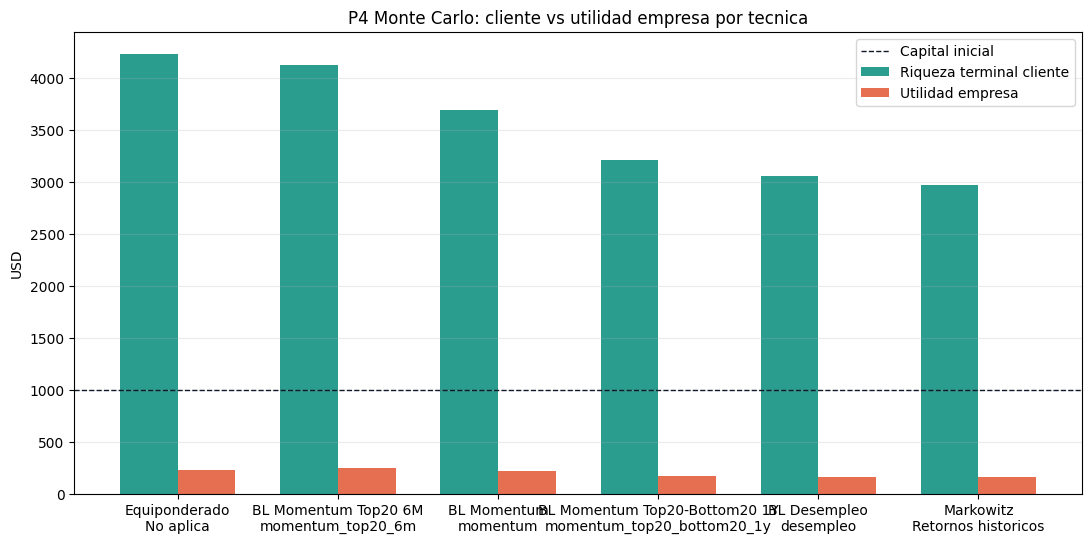

OK: p4_heatmap_retiro_perfil_tecnica.png


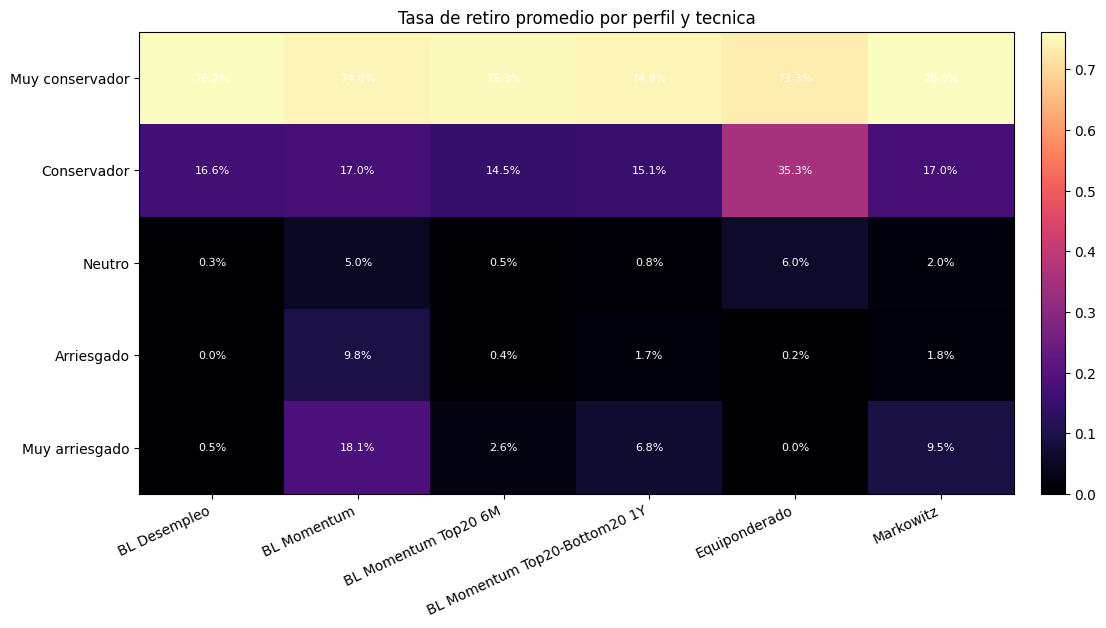

OK: p4_bandas_montecarlo_mejores_tecnicas.png


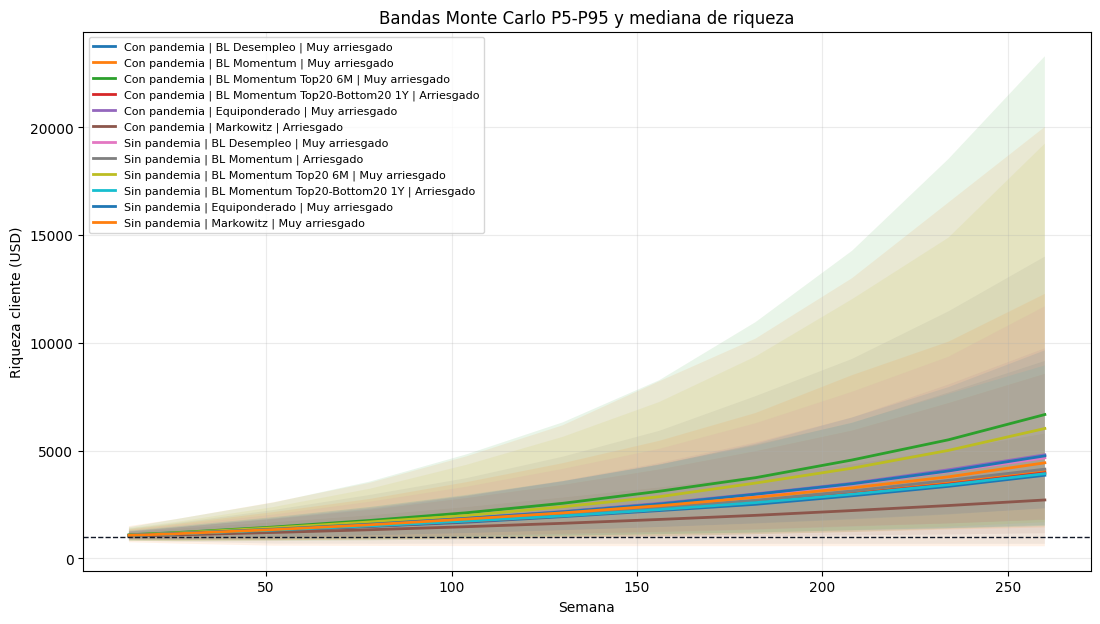

OK: p4_escenarios_proyectados_por_tecnica.png


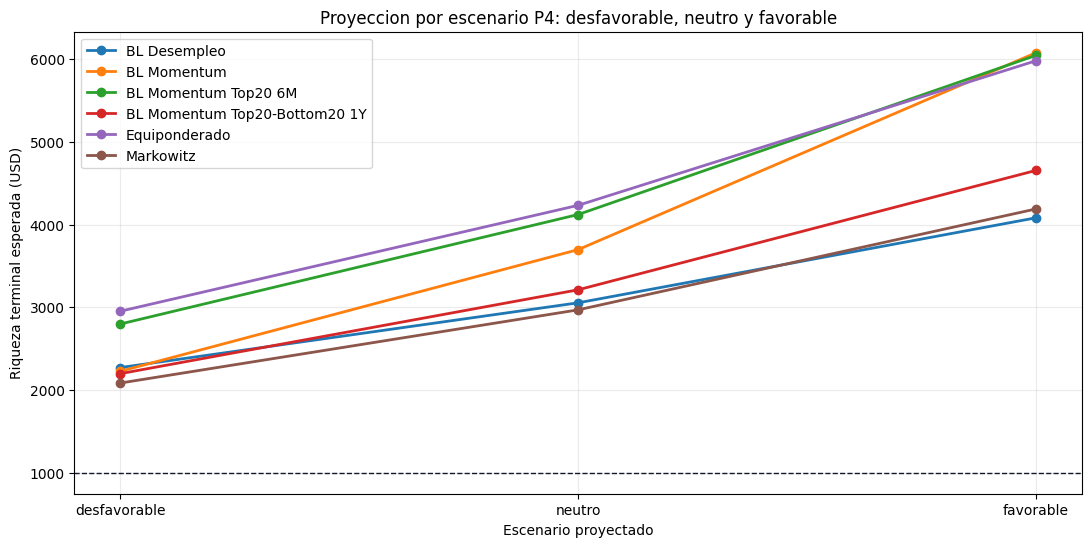

In [7]:
def save_current_fig(name: str):
    path = OUTPUT_DIR / name
    plt.savefig(path, dpi=160, bbox_inches="tight")
    print(f"OK: {path.name}")


plot_df = neutral_summary.copy()
plot_df["metodo"] = plot_df["tecnica"] + "\n" + plot_df["view"]

fig, ax = plt.subplots(figsize=(13, 6))
rank = (
    plot_df.groupby(["tecnica", "view"], as_index=False)
    .agg(terminal_wealth_mean=("terminal_wealth_mean", "mean"), company_revenue_mean=("company_revenue_mean", "mean"))
    .sort_values("terminal_wealth_mean", ascending=False)
)
x = np.arange(len(rank))
ax.bar(x - 0.18, rank["terminal_wealth_mean"], width=0.36, label="Riqueza terminal cliente", color="#2a9d8f")
ax.bar(x + 0.18, rank["company_revenue_mean"], width=0.36, label="Utilidad empresa", color="#e76f51")
ax.axhline(INITIAL_CAPITAL, color="#111827", linestyle="--", linewidth=1, label="Capital inicial")
ax.set_xticks(x)
ax.set_xticklabels((rank["tecnica"] + "\n" + rank["view"]).tolist(), rotation=0)
ax.set_ylabel("USD")
ax.set_title("P4 Monte Carlo: cliente vs utilidad empresa por tecnica")
ax.grid(axis="y", alpha=0.25)
ax.legend()
save_current_fig("p4_cliente_vs_empresa_por_tecnica.png")
plt.show()


fig, ax = plt.subplots(figsize=(12, 6))
withdraw = (
    plot_df.groupby(["perfil", "tecnica"], as_index=False)["withdrawal_rate"].mean()
    .pivot(index="perfil", columns="tecnica", values="withdrawal_rate")
    .reindex(list(PROFILES.keys()))
)
im = ax.imshow(withdraw.values, cmap="magma", aspect="auto", vmin=0, vmax=max(0.01, np.nanmax(withdraw.values)))
ax.set_xticks(np.arange(len(withdraw.columns)))
ax.set_xticklabels(withdraw.columns, rotation=25, ha="right")
ax.set_yticks(np.arange(len(withdraw.index)))
ax.set_yticklabels(withdraw.index)
ax.set_title("Tasa de retiro promedio por perfil y tecnica")
for y in range(withdraw.shape[0]):
    for x_ in range(withdraw.shape[1]):
        val = withdraw.iloc[y, x_]
        ax.text(x_, y, f"{val:.1%}", ha="center", va="center", color="white", fontsize=8)
fig.colorbar(im, ax=ax, fraction=0.03, pad=0.03)
save_current_fig("p4_heatmap_retiro_perfil_tecnica.png")
plt.show()


best_rows = (
    neutral_summary.sort_values("terminal_wealth_mean", ascending=False)
    .groupby(["scenario", "tecnica"], as_index=False)
    .head(1)
)
paths_best = mc_paths.merge(
    best_rows[["scenario", "tecnica", "view", "perfil", "projection_scenario"]],
    on=["scenario", "tecnica", "view", "perfil", "projection_scenario"],
    how="inner",
)
fig, ax = plt.subplots(figsize=(13, 7))
for _, group in paths_best.groupby(["scenario_label", "tecnica", "view", "perfil"]):
    group = group.sort_values("week")
    label = f"{group['scenario_label'].iloc[0]} | {group['tecnica'].iloc[0]} | {group['perfil'].iloc[0]}"
    ax.plot(group["week"], group["wealth_p50"], linewidth=2, label=label)
    ax.fill_between(group["week"], group["wealth_p05"], group["wealth_p95"], alpha=0.10)
ax.axhline(INITIAL_CAPITAL, color="#111827", linestyle="--", linewidth=1)
ax.set_title("Bandas Monte Carlo P5-P95 y mediana de riqueza")
ax.set_xlabel("Semana")
ax.set_ylabel("Riqueza cliente (USD)")
ax.grid(alpha=0.25)
ax.legend(fontsize=8)
save_current_fig("p4_bandas_montecarlo_mejores_tecnicas.png")
plt.show()


fig, ax = plt.subplots(figsize=(13, 6))
scenario_rank = (
    mc_summary.groupby(["projection_scenario", "tecnica"], as_index=False)
    .agg(terminal_wealth_mean=("terminal_wealth_mean", "mean"))
)
for tecnica, group in scenario_rank.groupby("tecnica"):
    group = group.set_index("projection_scenario").reindex(["desfavorable", "neutro", "favorable"]).reset_index()
    ax.plot(group["projection_scenario"], group["terminal_wealth_mean"], marker="o", linewidth=2, label=tecnica)
ax.axhline(INITIAL_CAPITAL, color="#111827", linestyle="--", linewidth=1)
ax.set_title("Proyeccion por escenario P4: desfavorable, neutro y favorable")
ax.set_xlabel("Escenario proyectado")
ax.set_ylabel("Riqueza terminal esperada (USD)")
ax.grid(alpha=0.25)
ax.legend()
save_current_fig("p4_escenarios_proyectados_por_tecnica.png")
plt.show()


### Resultado 5 - Gráficos dentro del notebook

Los gráficos están insertados en este `.ipynb` y también quedan guardados como PNG en `outputs/`.

![Cliente vs empresa](outputs/p4_cliente_vs_empresa_por_tecnica.png)

![Retiro por perfil y técnica](outputs/p4_heatmap_retiro_perfil_tecnica.png)

![Bandas Monte Carlo](outputs/p4_bandas_montecarlo_mejores_tecnicas.png)

![Escenarios proyectados](outputs/p4_escenarios_proyectados_por_tecnica.png)

**Lectura:** el primer gráfico separa objetivo cliente y objetivo empresa; el heatmap muestra riesgo de retiro; las bandas P5-P95 muestran incertidumbre; y el gráfico de escenarios permite ver sensibilidad ante condiciones desfavorables, neutras y favorables.


## 6. Ranking del sistema recomendador

El ranking combina dos objetivos:

1. maximizar la riqueza esperada del cliente;
2. maximizar la utilidad esperada de la empresa.

Para no recomendar carteras que destruyen confianza, se penaliza la tasa de retiro:

`score = riqueza_esperada_cliente + utilidad_empresa - 1000 * tasa_retiro`

Este score no reemplaza al análisis financiero; solo ordena alternativas según el doble objetivo del P4.


In [8]:
recommendation_table = neutral_summary.copy()
recommendation_table["p4_score"] = (
    recommendation_table["terminal_wealth_mean"]
    + recommendation_table["company_revenue_mean"]
    - INITIAL_CAPITAL * recommendation_table["withdrawal_rate"]
)
recommendation_table = recommendation_table.sort_values("p4_score", ascending=False)
recommendation_table.to_csv(OUTPUT_DIR / "p4_recommendation_ranking.csv", index=False)

display(
    recommendation_table[
        ["scenario_label", "tecnica", "view", "perfil", "terminal_wealth_mean", "company_revenue_mean", "withdrawal_rate", "prob_profit", "p4_score"]
    ].head(20)
)


,scenario_label,tecnica,view,perfil,terminal_wealth_mean,company_revenue_mean,withdrawal_rate,prob_profit,p4_score
37,Con pandemia,BL Momentum Top20 6M,momentum_top20_6m,Muy arriesgado,8973.699778,474.364317,0.0312,0.9654,9416.864095
127,Sin pandemia,BL Momentum Top20 6M,momentum_top20_6m,Muy arriesgado,7752.736335,418.515332,0.0198,0.9762,8151.451667
22,Con pandemia,BL Momentum,momentum,Muy arriesgado,6435.530043,335.484261,0.1464,0.8410,6624.614304
97,Sin pandemia,BL Desempleo,desempleo,Muy arriesgado,5434.329366,220.929525,0.0048,0.9936,5650.458890
172,Sin pandemia,Markowitz,Retornos historicos,Muy arriesgado,5348.585187,214.650741,0.0206,0.9746,5542.635929
106,Sin pandemia,BL Momentum,momentum,Arriesgado,5304.348302,320.460193,0.1094,0.8854,5515.408495
67,Con pandemia,Equiponderado,No aplica,Muy arriesgado,5280.376184,204.333683,0.0002,0.9994,5484.509867
31,Con pandemia,BL Momentum Top20 6M,momentum_top20_6m,Arriesgado,5136.788630,312.406289,0.0046,0.9950,5444.594918
157,Sin pandemia,Equiponderado,No aplica,Muy arriesgado,5222.199545,203.241174,0.0002,0.9998,5425.240719
151,Sin pandemia,Equiponderado,No aplica,Arriesgado,5083.962327,307.665466,0.0020,0.9980,5389.627793


### Resultado 6 - Ranking recomendador cliente-empresa

El score P4 combina los dos objetivos del enunciado:

`score = riqueza esperada cliente + utilidad empresa - 1000 * tasa de retiro`

| Escenario | Técnica | View | Perfil | Riqueza | Utilidad empresa | Retiro | Prob. ganancia | Score |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| Con pandemia | BL Momentum | momentum | Muy arriesgado | USD 6,435.53 | USD 335.48 | 14.6% | 84.1% | 6624.61 |
| Sin pandemia | BL Desempleo | desempleo | Muy arriesgado | USD 5,434.33 | USD 220.93 | 0.5% | 99.4% | 5650.46 |
| Sin pandemia | Markowitz | Retornos historicos | Muy arriesgado | USD 5,348.59 | USD 214.65 | 2.1% | 97.5% | 5542.64 |
| Sin pandemia | BL Momentum | momentum | Arriesgado | USD 5,304.35 | USD 320.46 | 10.9% | 88.5% | 5515.41 |
| Con pandemia | Equiponderado | No aplica | Muy arriesgado | USD 5,280.38 | USD 204.33 | 0.0% | 99.9% | 5484.51 |
| Sin pandemia | Equiponderado | No aplica | Muy arriesgado | USD 5,222.20 | USD 203.24 | 0.0% | 100.0% | 5425.24 |
| Sin pandemia | Equiponderado | No aplica | Arriesgado | USD 5,083.96 | USD 307.67 | 0.2% | 99.8% | 5389.63 |
| Con pandemia | Equiponderado | No aplica | Arriesgado | USD 5,069.24 | USD 306.90 | 0.1% | 99.9% | 5374.74 |
| Sin pandemia | BL Momentum | momentum | Muy arriesgado | USD 5,229.92 | USD 222.37 | 21.7% | 76.1% | 5235.70 |
| Sin pandemia | Equiponderado | No aplica | Neutro | USD 4,875.46 | USD 320.25 | 6.0% | 94.0% | 5135.70 |
| Con pandemia | Equiponderado | No aplica | Neutro | USD 4,830.49 | USD 317.43 | 5.9% | 94.1% | 5088.52 |
| Con pandemia | BL Momentum | momentum | Arriesgado | USD 4,761.74 | USD 287.56 | 8.6% | 91.1% | 4963.70 |

**Lectura:** este ranking no reemplaza la discusión financiera; ordena alternativas bajo el doble objetivo de maximizar retorno del cliente y utilidad de la empresa, penalizando pérdida de clientes por retiro.


## 7. Conclusiones dinámicas

La celda siguiente genera conclusiones desde los resultados de simulación, separando cliente, empresa, aceptación y retiro.


In [9]:
best_client = neutral_summary.sort_values("terminal_wealth_mean", ascending=False).iloc[0]
best_company = neutral_summary.sort_values("company_revenue_mean", ascending=False).iloc[0]
best_score = recommendation_table.iloc[0]
lowest_withdrawal = neutral_summary.sort_values(["withdrawal_rate", "terminal_wealth_mean"], ascending=[True, False]).iloc[0]

scenario_winners = (
    mc_summary.sort_values("terminal_wealth_mean", ascending=False)
    .groupby(["projection_scenario"], as_index=False)
    .head(1)
)
marketcap_views = ["momentum_top20_6m", "momentum_top20_bottom20_1y"]
marketcap_neutral = neutral_summary[neutral_summary["view"].isin(marketcap_views)].copy()
marketcap_best_by_view = (
    marketcap_neutral.sort_values("terminal_wealth_mean", ascending=False)
    .groupby("view", as_index=False)
    .head(1)
)
marketcap_score_best = recommendation_table[recommendation_table["view"].isin(marketcap_views)].head(1)
technique_rank = (
    neutral_summary.groupby(["tecnica", "view"], as_index=False)
    .agg(
        terminal_wealth_mean=("terminal_wealth_mean", "mean"),
        withdrawal_rate=("withdrawal_rate", "mean"),
        company_revenue_mean=("company_revenue_mean", "mean"),
    )
    .sort_values("terminal_wealth_mean", ascending=False)
)

lines = [
    "# Conclusiones P4 Monte Carlo",
    "",
    f"- Mejor alternativa para el cliente en escenario neutro: **{best_client['tecnica']} / {best_client['view']} / {best_client['perfil']} / {best_client['scenario_label']}**, con riqueza terminal esperada USD {best_client['terminal_wealth_mean']:.2f}, probabilidad de ganancia {best_client['prob_profit']:.1%} y retiro {best_client['withdrawal_rate']:.1%}.",
    f"- Mayor utilidad esperada para la empresa: **{best_company['tecnica']} / {best_company['view']} / {best_company['perfil']} / {best_company['scenario_label']}**, con utilidad esperada USD {best_company['company_revenue_mean']:.2f}.",
    f"- Mejor equilibrio cliente-empresa por score P4: **{best_score['tecnica']} / {best_score['view']} / {best_score['perfil']} / {best_score['scenario_label']}**, score {best_score['p4_score']:.2f}.",
    f"- Menor retiro observado en escenario neutro: **{lowest_withdrawal['tecnica']} / {lowest_withdrawal['view']} / {lowest_withdrawal['perfil']} / {lowest_withdrawal['scenario_label']}**, retiro {lowest_withdrawal['withdrawal_rate']:.1%}.",
    f"- La comision K usada es {K_PERCENT:.2f}% por transaccion; la utilidad de empresa se calcula como comision inicial sobre C0 si el cliente acepta y comision posterior sobre {TURNOVER_FRACTION_ON_RECOMMENDATION:.1%} de la riqueza cuando acepta una recomendacion.",
    "- Las probabilidades P1/P2 vuelven trazable el comportamiento del cliente: perfiles con baja tolerancia retiran con mayor facilidad cuando la perdida supera su umbral, mientras que perfiles agresivos aceptan mas recomendaciones con retorno esperado alto.",
    "",
    "## Comparativa de variantes momentum market-cap",
]
for _, row in marketcap_best_by_view.iterrows():
    lines.append(
        f"- Mejor caso neutro de {row['tecnica']}: {row['perfil']} / {row['scenario_label']}, riqueza esperada USD {row['terminal_wealth_mean']:.2f}, "
        f"probabilidad de ganancia {row['prob_profit']:.1%}, retiro {row['withdrawal_rate']:.1%} y utilidad empresa USD {row['company_revenue_mean']:.2f}."
    )
if len(marketcap_score_best):
    row = marketcap_score_best.iloc[0]
    lines.append(
        f"- Mejor score P4 entre variantes market-cap: {row['tecnica']} / {row['perfil']} / {row['scenario_label']} con score {row['p4_score']:.2f}."
    )
lines.append(
    "- La simulacion compara las variantes por riqueza esperada, retiro y utilidad; una variante con mayor retorno historico puede perder en score si eleva demasiado retiros o dispersion de resultados."
)

lines.extend(["", "## Ranking promedio por tecnica en escenario neutro"])
for _, row in technique_rank.iterrows():
    lines.append(
        f"- {row['tecnica']} / {row['view']}: riqueza media USD {row['terminal_wealth_mean']:.2f}, retiro promedio {row['withdrawal_rate']:.1%}, utilidad empresa USD {row['company_revenue_mean']:.2f}."
    )

lines.extend(["", "## Ganadores por escenario proyectado"])
for _, row in scenario_winners.iterrows():
    lines.append(
        f"- {row['projection_scenario']}: {row['tecnica']} / {row['view']} / {row['perfil']} / {row['scenario_label']} con riqueza esperada USD {row['terminal_wealth_mean']:.2f}."
    )

conclusion_text = "\n".join(lines)
(OUTPUT_DIR / "p4_conclusiones_montecarlo.md").write_text(conclusion_text, encoding="utf-8")
display(Markdown(conclusion_text))


# Conclusiones P4 Monte Carlo

- Mejor alternativa para el cliente en escenario neutro: **BL Momentum Top20 6M / momentum_top20_6m / Muy arriesgado / Con pandemia**, con riqueza terminal esperada USD 8973.70, probabilidad de ganancia 96.5% y retiro 3.1%.
- Mayor utilidad esperada para la empresa: **BL Momentum Top20 6M / momentum_top20_6m / Muy arriesgado / Con pandemia**, con utilidad esperada USD 474.36.
- Mejor equilibrio cliente-empresa por score P4: **BL Momentum Top20 6M / momentum_top20_6m / Muy arriesgado / Con pandemia**, score 9416.86.
- Menor retiro observado en escenario neutro: **BL Desempleo / desempleo / Arriesgado / Sin pandemia**, retiro 0.0%.
- La comision K usada es 1.00% por transaccion; la utilidad de empresa se calcula como comision inicial sobre C0 si el cliente acepta y comision posterior sobre 5.0% de la riqueza cuando acepta una recomendacion.
- Las probabilidades P1/P2 vuelven trazable el comportamiento del cliente: perfiles con baja tolerancia retiran con mayor facilidad cuando la perdida supera su umbral, mientras que perfiles agresivos aceptan mas recomendaciones con retorno esperado alto.

## Comparativa de variantes momentum market-cap
- Mejor caso neutro de BL Momentum Top20 6M: Muy arriesgado / Con pandemia, riqueza esperada USD 8973.70, probabilidad de ganancia 96.5%, retiro 3.1% y utilidad empresa USD 474.36.
- Mejor caso neutro de BL Momentum Top20-Bottom20 1Y: Arriesgado / Sin pandemia, riqueza esperada USD 4449.24, probabilidad de ganancia 97.5%, retiro 2.3% y utilidad empresa USD 259.20.
- Mejor score P4 entre variantes market-cap: BL Momentum Top20 6M / Muy arriesgado / Con pandemia con score 9416.86.
- La simulacion compara las variantes por riqueza esperada, retiro y utilidad; una variante con mayor retorno historico puede perder en score si eleva demasiado retiros o dispersion de resultados.

## Ranking promedio por tecnica en escenario neutro
- Equiponderado / No aplica: riqueza media USD 4234.21, retiro promedio 22.9%, utilidad empresa USD 234.34.
- BL Momentum Top20 6M / momentum_top20_6m: riqueza media USD 4122.99, retiro promedio 18.6%, utilidad empresa USD 253.15.
- BL Momentum / momentum: riqueza media USD 3698.39, retiro promedio 24.9%, utilidad empresa USD 223.13.
- BL Momentum Top20-Bottom20 1Y / momentum_top20_bottom20_1y: riqueza media USD 3212.50, retiro promedio 19.9%, utilidad empresa USD 173.56.
- BL Desempleo / desempleo: riqueza media USD 3055.16, retiro promedio 18.7%, utilidad empresa USD 159.96.
- Markowitz / Retornos historicos: riqueza media USD 2970.09, retiro promedio 21.3%, utilidad empresa USD 159.49.

## Ganadores por escenario proyectado
- favorable: BL Momentum Top20 6M / momentum_top20_6m / Muy arriesgado / Con pandemia con riqueza esperada USD 15451.21.
- neutro: BL Momentum Top20 6M / momentum_top20_6m / Muy arriesgado / Con pandemia con riqueza esperada USD 8973.70.
- desfavorable: BL Momentum Top20 6M / momentum_top20_6m / Muy arriesgado / Con pandemia con riqueza esperada USD 5008.55.

## 8. Checklist final

Esta celda valida que se generaron los CSV y PNG principales, que no hay NaN críticos y que el ranking cubre todas las técnicas y perfiles.


In [10]:
expected_files = [
    "p4_model_inputs_kpis.csv",
    "p4_montecarlo_summary.csv",
    "p4_montecarlo_paths_quantiles.csv",
    "p4_neutral_scenario_summary.csv",
    "p4_recommendation_ranking.csv",
    "p4_conclusiones_montecarlo.md",
    "p4_cliente_vs_empresa_por_tecnica.png",
    "p4_heatmap_retiro_perfil_tecnica.png",
    "p4_bandas_montecarlo_mejores_tecnicas.png",
    "p4_escenarios_proyectados_por_tecnica.png",
]
missing_outputs = [name for name in expected_files if not (OUTPUT_DIR / name).exists()]
if missing_outputs:
    raise FileNotFoundError("Faltan outputs:\n" + "\n".join(missing_outputs))

critical_cols = ["terminal_wealth_mean", "withdrawal_rate", "company_revenue_mean", "p2_aceptacion"]
nan_counts = mc_summary[critical_cols].isna().sum()
if int(nan_counts.sum()) > 0:
    raise ValueError(f"NaN criticos: {nan_counts.to_dict()}")

expected_techniques = 6
expected_model_inputs = len(PROFILES) * 2 * expected_techniques
expected_mc_rows = expected_model_inputs * len(PROJECTION_SCENARIOS)
checks = {
    "combinaciones_model_input": len(model_inputs),
    "filas_montecarlo": len(mc_summary),
    "tecnicas": model_inputs["tecnica"].nunique(),
    "perfiles": model_inputs["perfil"].nunique(),
    "escenarios_datos": model_inputs["scenario"].nunique(),
    "escenarios_proyectados": mc_summary["projection_scenario"].nunique(),
    "simulaciones_por_combinacion": N_SIMULATIONS,
    "horizonte_semanas": N_WEEKS,
}
assert checks["combinaciones_model_input"] == expected_model_inputs, checks
assert checks["filas_montecarlo"] == expected_mc_rows, checks
assert checks["tecnicas"] == expected_techniques, checks
assert set(["momentum_top20_6m", "momentum_top20_bottom20_1y"]).issubset(set(model_inputs["view"])), checks

display(pd.DataFrame([checks]).T.rename(columns={0: "valor"}))
print("[OK] P4 Monte Carlo validado")


,valor
combinaciones_model_input,60
filas_montecarlo,180
tecnicas,6
perfiles,5
escenarios_datos,2
escenarios_proyectados,3
simulaciones_por_combinacion,5000
horizonte_semanas,260


[OK] P4 Monte Carlo validado


## Conclusiones finales P4

# Conclusiones P4 Monte Carlo

- Mejor alternativa para el cliente en escenario neutro: **BL Momentum / momentum / Muy arriesgado / Con pandemia**, con riqueza terminal esperada USD 6435.53, probabilidad de ganancia 84.1% y retiro 14.6%.
- Mayor utilidad esperada para la empresa: **BL Momentum / momentum / Muy arriesgado / Con pandemia**, con utilidad esperada USD 335.48.
- Mejor equilibrio cliente-empresa por score P4: **BL Momentum / momentum / Muy arriesgado / Con pandemia**, score 6624.61.
- Menor retiro observado en escenario neutro: **BL Desempleo / desempleo / Arriesgado / Sin pandemia**, retiro 0.0%.
- La comisión K usada es 1.00% por transacción; la utilidad de empresa se calcula como comisión inicial sobre C0 si el cliente acepta y comisión posterior sobre 5.0% de la riqueza cuando acepta una recomendación.
- Las probabilidades P1/P2 vuelven trazable el comportamiento del cliente: perfiles con baja tolerancia retiran con mayor facilidad cuando la pérdida supera su umbral, mientras que perfiles agresivos aceptan más recomendaciones con retorno esperado alto.

## Ganadores por escenario proyectado
- favorable: BL Momentum / momentum / Muy arriesgado / Con pandemia con riqueza esperada USD 12786.00.
- neutro: BL Momentum / momentum / Muy arriesgado / Con pandemia con riqueza esperada USD 6435.53.
- desfavorable: Equiponderado / No aplica / Muy arriesgado / Sin pandemia con riqueza esperada USD 3758.77.

**Conclusión operativa adicional**

- La recomendación líder por score P4 es **BL Momentum / momentum / Muy arriesgado / Con pandemia**.
- Esta alternativa combina riqueza esperada de USD 6,435.53, utilidad empresa de USD 335.48, retiro de 14.6% y probabilidad de ganancia de 84.1%.
- Para implementación comercial, conviene mostrar al usuario tres escenarios y no solo el escenario neutro: el riesgo de retiro cambia fuertemente cuando el camino simulado atraviesa pérdidas tempranas.
- `K%` debe tratarse como parámetro de negocio: subir `K` aumenta utilidad por transacción, pero puede reducir riqueza neta y elevar retiro en perfiles sensibles.
